# Coarse-grain Homo-4mer 8y7s

Author: Sikao Guo
Modified by: Yue Moon Ying

This file includes a tutorial of how to automatically set up a coarse-grained model of a protein complex given a pdb id as an input using `ionerdss`. The model we are using is `8y7s`, which corresponds to benzaldehyde lyase mutant M6 from Herbiconiux sp. SALV-R1. More information about the protein structure is available at [8y7s on RCSB PDB](https://www.rcsb.org/structure/8Y7S).

## 0. Import packages

The only required package in this example is `ionerdss`. The rest are for analysis and visualization purposes.
- `subprocess` is used to invoke PyMOL from within Python to run a .pml script that presumably generates an image.
- `os.path.*` is used to correctly expand `~` to the full path of the user's home directory and ensures you get an absolute path, not a relative one, so all file references are unambiguous. This package is called to generate and display the images output by PyMOL, within the given save directory `save_folder`.
- `IPython.display` displays images in ipython notebook

In [1]:
import ionerdss as ion
from ionerdss.model.pdb.core import PDBModel
import subprocess # for running pymol
from os.path import expanduser, abspath # for expanding `~` in path
from IPython.display import display, Image # for image display in ipynb

/Users/yueying/Workspace/ionerdss/ionerdss/__init__.py:63: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## 1. Set the PDB ID and save directory

In [2]:
# Your PDB id
pdb_id = '8y7s'

# Make sure that pdb id is all lower case
pdb_id = pdb_id.lower()

# Set save directory
save_folder = '~/Documents/' + pdb_id + '_dir'

In [3]:
# (optional) show the thumbnail of the protein structure form RCSB PDB
# Get the image file from RCSB and display the image
image_url = f"https://cdn.rcsb.org/images/structures/{pdb_id}_assembly-1.jpeg"
display(Image(url=image_url))

## 2. Set up and create a coarse-grained model

- Initialize the pdb model given pdb id and save folder
- Set up the coarse grain model from pdb model. For all tunable parameters, see [`pdb_model.coarse_grain`](https://ionerdss.readthedocs.io/en/latest/ionerdss.nerdss_model.html#ionerdss.nerdss_model.pdb_model.PDBModel.coarse_grain)
- Identify, align, and regularize all molecular chains so that repeated chains share the same relative geometry. For all tunable parameters, see [`pdb_model.regularize_repeated_chains`](https://ionerdss.readthedocs.io/en/latest/ionerdss.nerdss_model.html#ionerdss.nerdss_model.pdb_model.PDBModel.regularize_repeated_chains)

In [4]:
# initialize the pdb model given pdb id and save folder
pdb_model = PDBModel(pdb_id=pdb_id, save_dir=save_folder)

# set up the coarse grain model from pdb model,
# by detecting binding interfaces between chains based on atomic distances
# for all tunable parameters see
# https://ionerdss.readthedocs.io/en/latest/ionerdss.model.html#ionerdss.model.pdb_model.PDBModel.coarse_grain
# set standard_output=True to see the determined interfaces
pdb_model.run_pipeline()

cg_model ============== 1
{'chains': [<Chain id=A>, <Chain id=B>, <Chain id=E>, <Chain id=F>], 'COMs': [Coords(x=-34.339, y=24.679, z=53.314), Coords(x=-30.535, y=-12.090, z=71.740), Coords(x=-6.333, y=14.933, z=30.687), Coords(x=4.566, y=-13.369, z=59.113)], 'radii': [np.float32(24.207155), np.float32(24.304047), np.float32(24.132565), np.float32(24.203894)], 'interfaces': [['B', 'E'], ['A', 'F'], ['A', 'F'], ['B', 'E']], 'interface_coords': [[Coords(x=-40.994, y=9.390, z=65.817), Coords(x=-22.721, y=22.431, z=40.715)], [Coords(x=-40.094, y=6.270, z=68.488), Coords(x=-13.846, y=-15.129, z=68.754)], [Coords(x=-19.311, y=22.693, z=40.960), Coords(x=7.027, y=1.361, z=39.422)], [Coords(x=-11.189, y=-16.568, z=66.454), Coords(x=7.656, y=-2.259, z=41.536)]], 'interface_residues': [[[143, 146, 147, 179, 184, 185, 186, 187, 188, 189, 190, 302, 303, 306, 314, 315, 316, 317], [26, 48, 74, 75, 78, 79, 82, 109, 110, 111, 112, 120, 123, 278, 279, 415, 416, 418, 448, 449, 452, 477, 498, 499, 502, 5

/Users/yueying/Workspace/ionerdss/ionerdss/model/pdb/detect_repeats.py:88: UserWarning: /Users/yueying/Documents/8y7s_dir/8y7s.cif: Missing mmCIF entity_poly info. Falling back to sequence alignment.
  warnings.warn(f"{pdb_id}: Missing mmCIF entity_poly info. Falling back to sequence alignment.")


[DEBUG] Template: A_1, Coord: (-6.655, -15.289, 12.503)
[DEBUG] Template: E_1, Coord: (11.618, -2.249, -12.599)
[DEBUG] Template: E_2, Coord: (11.434, -1.981, -12.729)
[DEBUG] Template: A_2, Coord: (13.360, -13.572, 8.735)
[DEBUG] Template: A_3, Coord: (-6.737, -15.446, 12.568)
[DEBUG] Template: E_3, Coord: (13.360, -13.572, 8.735)
{'A': 'A', 'B': 'A', 'E': 'E', 'F': 'E'}
[['A', 'B'], ['E', 'F']]
{'chains': [<Chain id=A>, <Chain id=B>, <Chain id=E>, <Chain id=F>], 'COMs': [Coords(x=-34.339, y=24.679, z=53.314), Coords(x=-30.535, y=-12.090, z=71.740), Coords(x=-6.333, y=14.933, z=30.687), Coords(x=4.566, y=-13.369, z=59.113)], 'radii': [np.float32(24.207155), np.float32(24.304047), np.float32(24.132565), np.float32(24.203894)], 'interfaces': [['B', 'E'], ['A', 'F'], ['A', 'F'], ['B', 'E']], 'interface_coords': [[Coords(x=-40.994, y=9.390, z=65.817), Coords(x=-22.721, y=22.431, z=40.715)], [Coords(x=-40.094, y=6.270, z=68.488), Coords(x=-13.846, y=-15.129, z=68.754)], [Coords(x=-19.311, 

## 3. (Optional) Call PyMOL script to visualize the coarse-grained model

- *REQUIRES*: PyMOL
- Note: if PyMOL is installed but you are still getting `FileNotFoundError: [Errno 2] No such file or directory: 'pymol'`, this means that Python can't find the `pymol` executable in your system's `PATH` (you can confirm this with `which pymol` in terminal). This problem might come from installing PyMOL through Anaconda (`conda install -c schrodinger pymol`) and then the pymol binary might only be available inside the conda environment.
- If you do not want to install it outside the conda environment, you can fix it by using the full path via replacing `"pymol"` in `subprocess.run` with the full path (e.g. `/Users/username/miniconda3/envs/myenv/bin/pymol`)

PyMOL>load /Users/yueying/Documents/8y7s_dir/regularized_coarse_grained_structure.cif, coarse_grained
 ExecutiveLoad-Detail: Detected mmCIF
 CmdLoad: "/Users/yueying/Documents/8y7s_dir/regularized_coarse_grained_structure.cif" loaded as "coarse_grained".
PyMOL>hide everything
PyMOL>show spheres, name COM
PyMOL>show spheres, name INT
PyMOL>set sphere_scale, 1.0
 Setting: sphere_scale set to 1.00000.
PyMOL>color red, name COM
 Executive: Colored 4 atoms.
PyMOL>color blue, name INT
 Executive: Colored 12 atoms.
PyMOL>pseudoatom com_A, pos=[-34.339, 24.679, 53.314], color=red
 ObjMol: created com_A/PSDO/P/PSD`1 /PS1
PyMOL>pseudoatom int_A_1, pos=[-41.347, 10.365, 67.061], color=blue
 ObjMol: created int_A_1/PSDO/P/PSD`1 /PS1
PyMOL>distance line1, com_A, int_A_1
 Executive: object "line1" created.
PyMOL>set dash_width, 4, line1
 Setting: dash_width set to 4.00000 in object "line1".
PyMOL>set dash_gap, 0.5, line1
 Setting: dash_gap set to 0.50000 in object "line1".
PyMOL>pseudoatom int_A_2, 

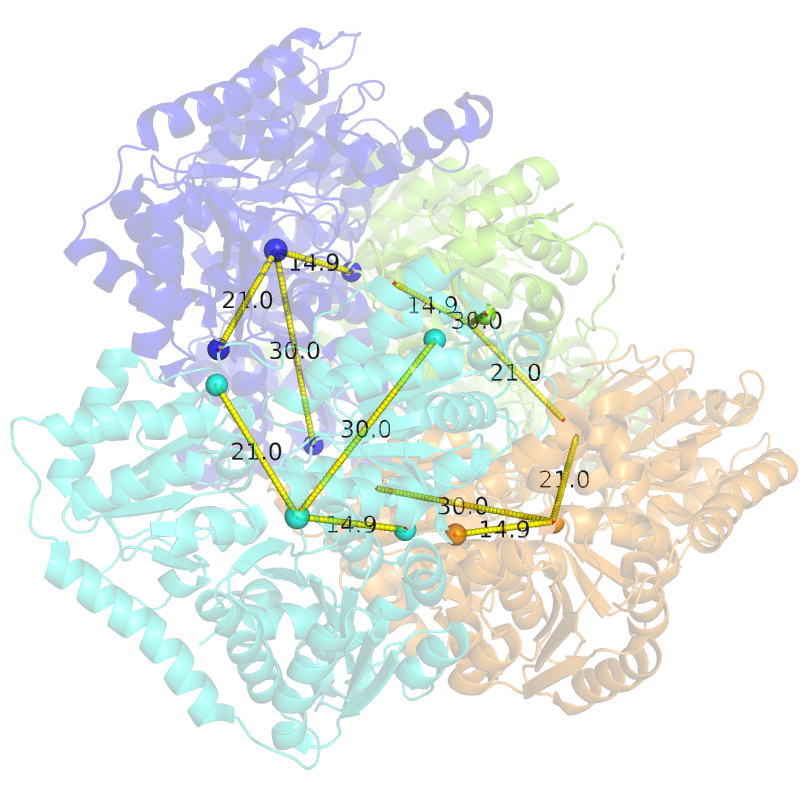

In [5]:
# Get the absolute save directory path
if save_folder.startswith('~'):
    abs_save_folder = expanduser(save_folder)
abs_save_folder = abspath(abs_save_folder)

# Call the PyMOL script to draw the image for the coarse-grained model
subprocess.run(["pymol", "-cq", f"{abs_save_folder}/visualize_regularized_coarse_grained.pml"], check=True)

# Display the coarse-grained image
display(Image(filename=f"{abs_save_folder}/comparison_regularized.png"))